In [ ]:
# Import libraries for data manipulation and numerical computations.
import numpy as np
import pandas as pd

# Import libraries for data visualization.
import seaborn as sns
import matplotlib.pyplot as plt

# Import tools for model evaluation and hyperparameter tuning.
from sklearn.model_selection import cross_val_score, GridSearchCV

# Import performance metrics for evaluating classification models.
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report

)



In [ ]:
# Loading the dataset
df=pd.read_excel('E Commerce Dataset.xlsx')

In [ ]:
df.head()


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4,Mobile Phone,3,6,Debit Card,Female,3,3,Laptop & Accessory,2,Single,9,1,11,1,1,5,159.93
1,50002,1,0,Phone,1,8,UPI,Male,3,4,Mobile,3,Single,7,1,15,0,1,0,120.90
2,50003,1,0,Phone,1,30,Debit Card,Male,2,4,Mobile,3,Single,6,1,14,0,1,3,120.28
3,50004,1,0,Phone,3,15,Debit Card,Male,2,4,Laptop & Accessory,5,Single,8,0,23,0,1,3,134.07
4,50005,1,0,Phone,1,12,CC,Male,3,3,Mobile,5,Single,3,0,11,1,1,3,129.60


In [ ]:
# Generate descriptive statistics for all numerical columns in the dataset.
# It provides summary measures such as count, mean, standard deviation,
# minimum, maximum, and quartile values (25%, 50%, and 75%).

df.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000
mean,52815.500000,0.168384,9.707993,1.654707,15.566785,2.934636,3.688988,3.066785,4.214032,0.284902,15.674600,1.716874,2.961812,4.459325,177.223030
std,1625.385339,0.374240,8.626638,0.915389,8.345961,0.705528,1.023999,1.380194,2.583586,0.451408,3.591058,1.857640,2.879248,3.570626,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,1.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,8.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,15.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


In [ ]:
# Checking the datatype of the coulmns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5630 non-null   int64  
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5630 non-null   int64  
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5630 non-null   int64  
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [ ]:
# Checking for any NAN values
df.isna().sum()


,0
CustomerID,0
Churn,0
Tenure,0
PreferredLoginDevice,0
CityTier,0
WarehouseToHome,0
PreferredPaymentMode,0
Gender,0
HourSpendOnApp,0
NumberOfDeviceRegistered,0


In [ ]:
# Remove duplicate rows and drop the CustomerID column.
df_1 = df.drop_duplicates().drop(columns='CustomerID')

# Standardize the login device values for consistency.
df_1['PreferredLoginDevice'] = df_1['PreferredLoginDevice'].replace({
    'Phone': 'Mobile Phone'
})

# Display the frequency of each login device.
df_1['PreferredLoginDevice'].value_counts()

/tmp/ipykernel_1816/3288327665.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_1['PreferredLoginDevice'].replace({'Phone':'Mobile Phone'},inplace=True)


,count
PreferredLoginDevice,
Mobile Phone,3996
Computer,1634


In [ ]:
# Standardize the values in the PreferredPaymentMode column.
# This ensures consistent category names for analysis.

df_1['PreferredPaymentMode'] = df_1['PreferredPaymentMode'].replace({
    'Cash on Delivery': 'COD',
    'CC': 'Credit Card'
})

# Display the frequency of each payment mode after replacement.
df_1['PreferredPaymentMode'].value_counts()

,count
PreferredPaymentMode,
Debit Card,2314
Credit Card,1774
E wallet,614
COD,514
UPI,414


In [ ]:
# Rename columns to make their names shorter and easier to understand.
df_1.rename(
    columns={
        'PreferedOrderCat': 'Category',
        'PreferredLoginDevice': 'Login_Device',
        'PreferredPaymentMode': 'Payment_mode'
    },
    inplace=True
)

# Replace the value 'Mobile' with 'Mobile Phone' in the Category column.
df_1['Category'] = df_1['Category'].replace({'Mobile': 'Mobile Phone'})

# Display the frequency of each category.
df_1['Category'].value_counts()

,count
Category,
Laptop & Accessory,2050
Mobile Phone,1271
Fashion,826
Mobile,809
Grocery,410
Others,264


In [ ]:
# Display the frequency of each category in the MaritalStatus column.
print(df_1['MaritalStatus'].value_counts())

# Display the frequency distribution of the OrderCount column.
print(df_1['OrderCount'].value_counts())

MaritalStatus
Married     2986
Single      1796
Divorced     848
Name: count, dtype: int64
OrderCount
2     2283
1     1751
3      371
7      206
4      204
5      181
8      172
6      137
9       62
12      54
11      51
10      36
14      36
15      33
13      30
16      23
Name: count, dtype: int64


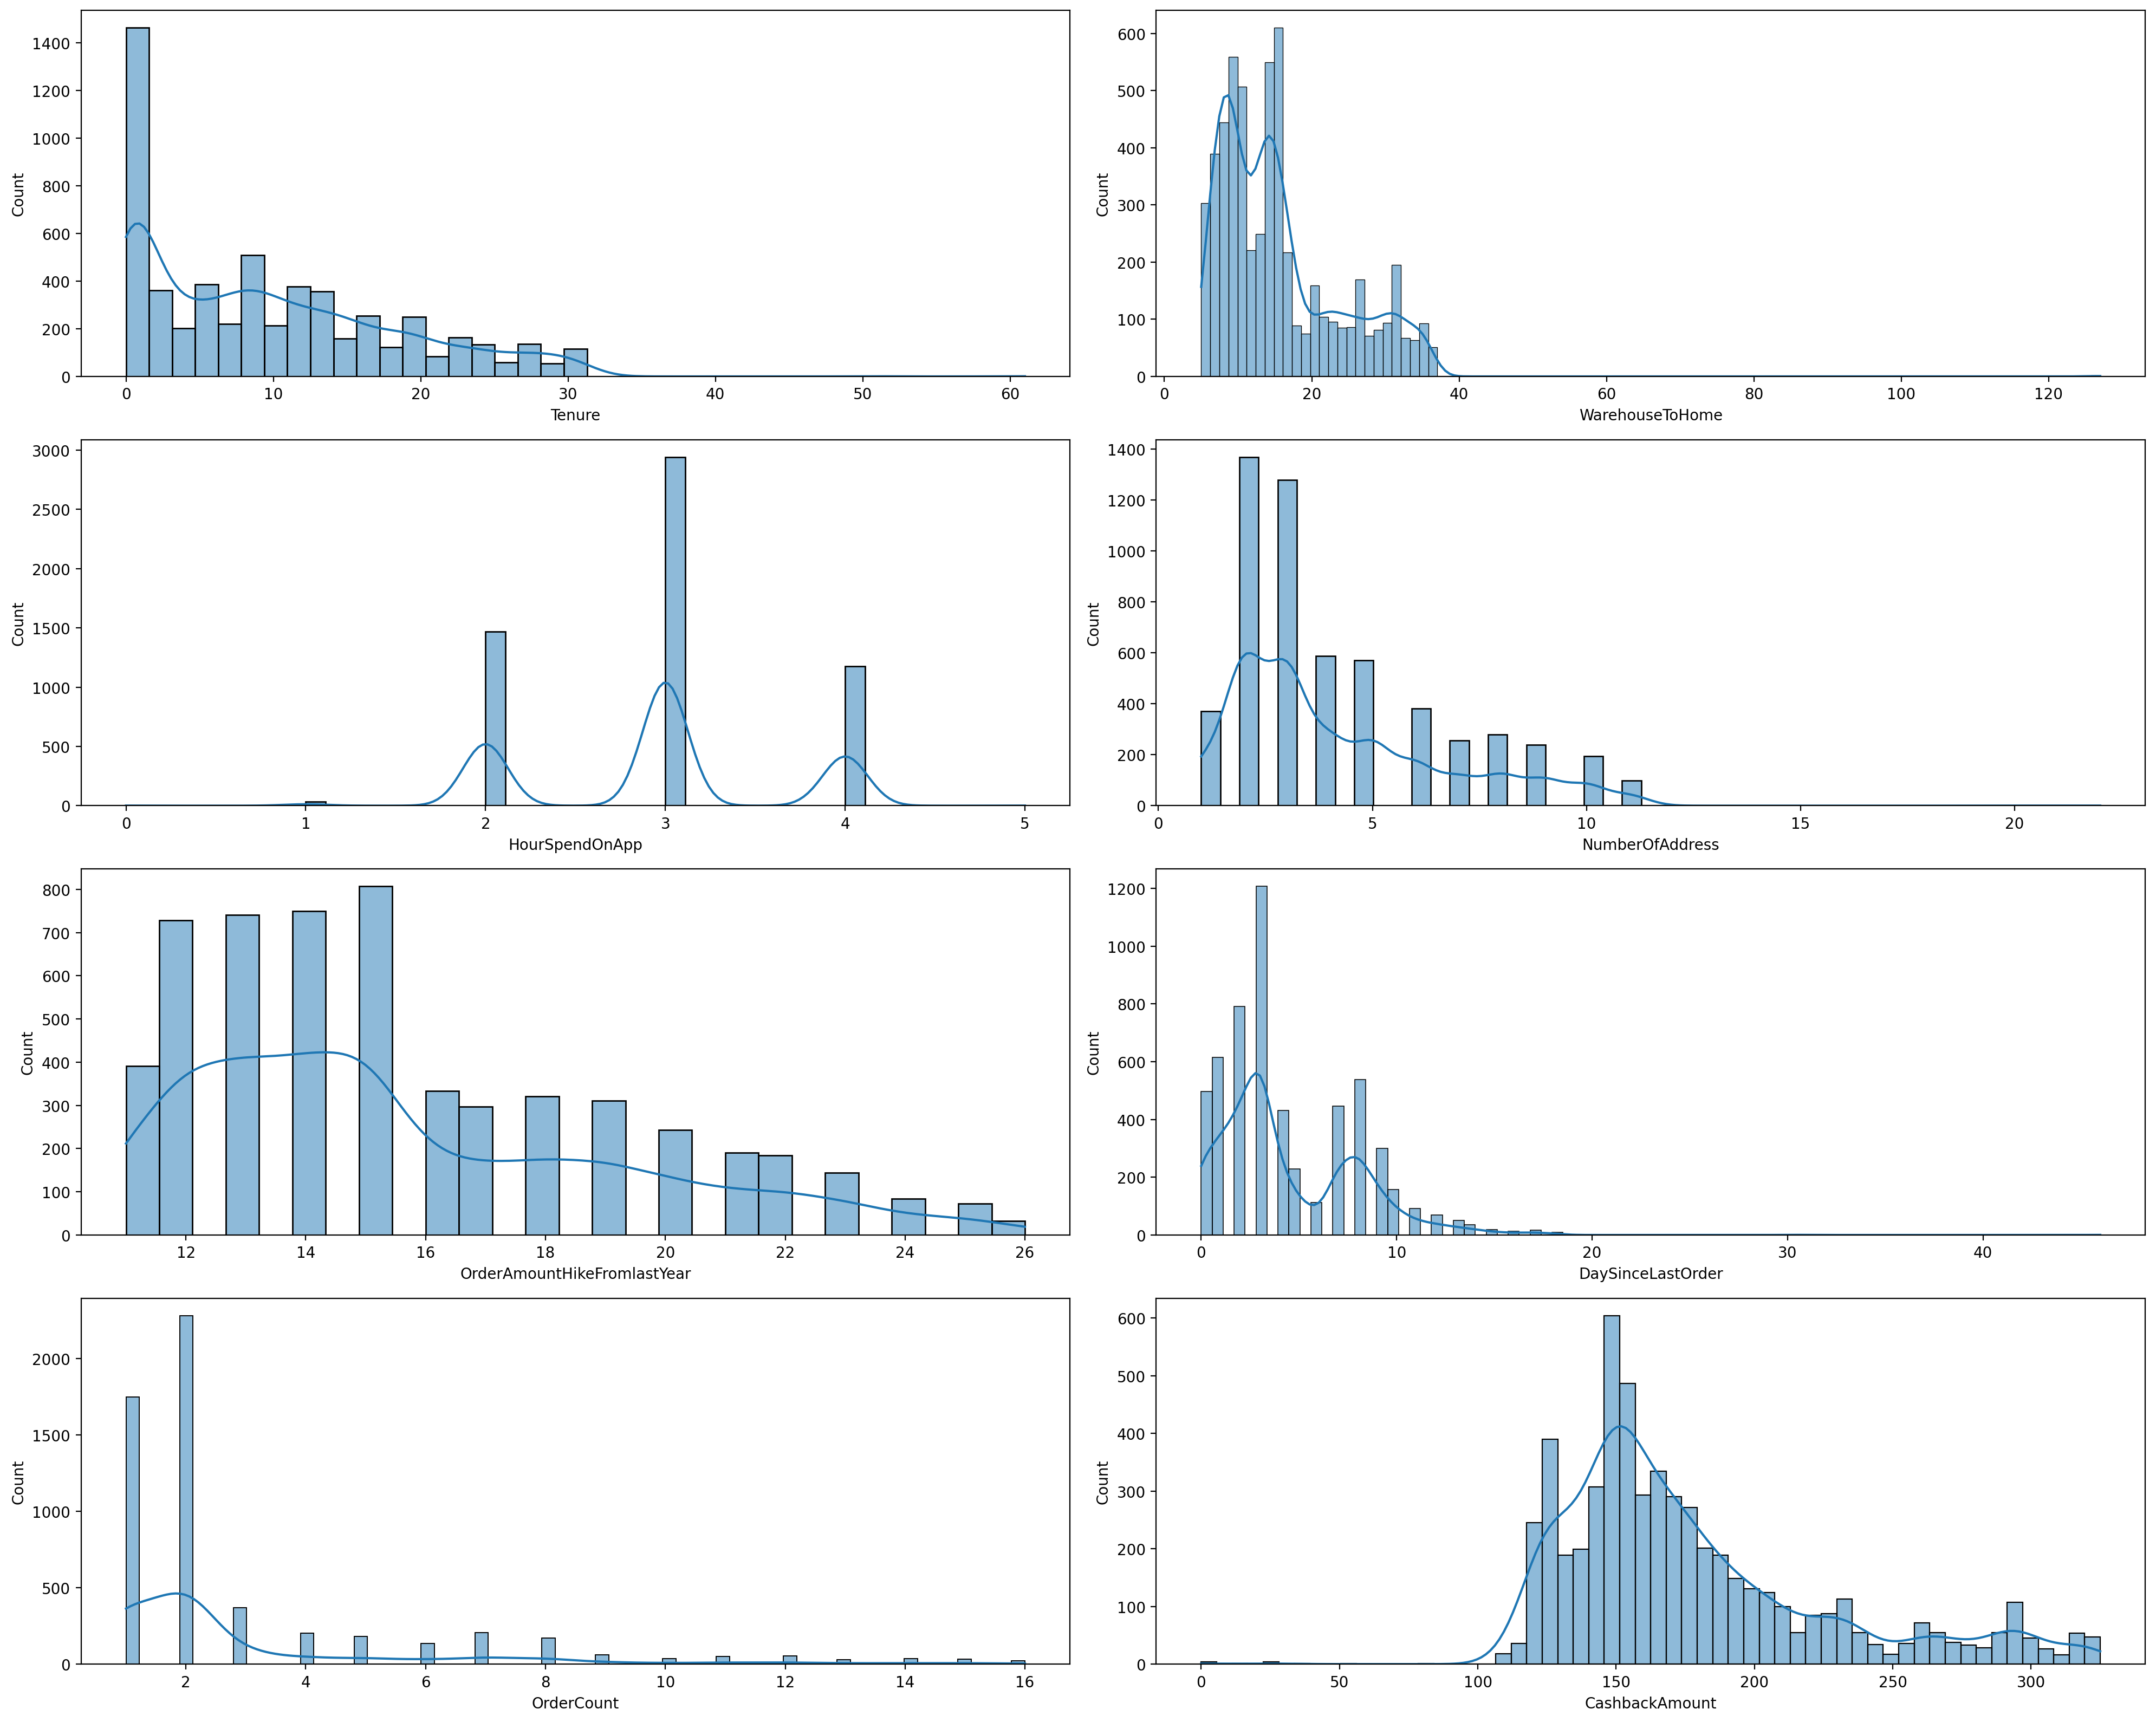

In [ ]:
# Plot histograms with KDE curves for the selected numerical features
# to understand their distributions.

plt.figure(figsize=(20, 16), dpi=200)

# List of numerical features to visualize.
hist = [
    'Tenure', 'WarehouseToHome', 'HourSpendOnApp',
    'NumberOfAddress', 'OrderAmountHikeFromlastYear',
    'DaySinceLastOrder', 'OrderCount', 'CashbackAmount'
]

# Create a histogram for each feature.
for i in range(len(hist)):
    plt.subplot(4, 2, i + 1)

    sns.histplot(
        data=df_1,
        x=hist[i],
        kde=True        # Overlay the Kernel Density Estimation (KDE) curve.
    )

# Adjust spacing between plots.
plt.tight_layout()

# Display all the histograms.
plt.show()

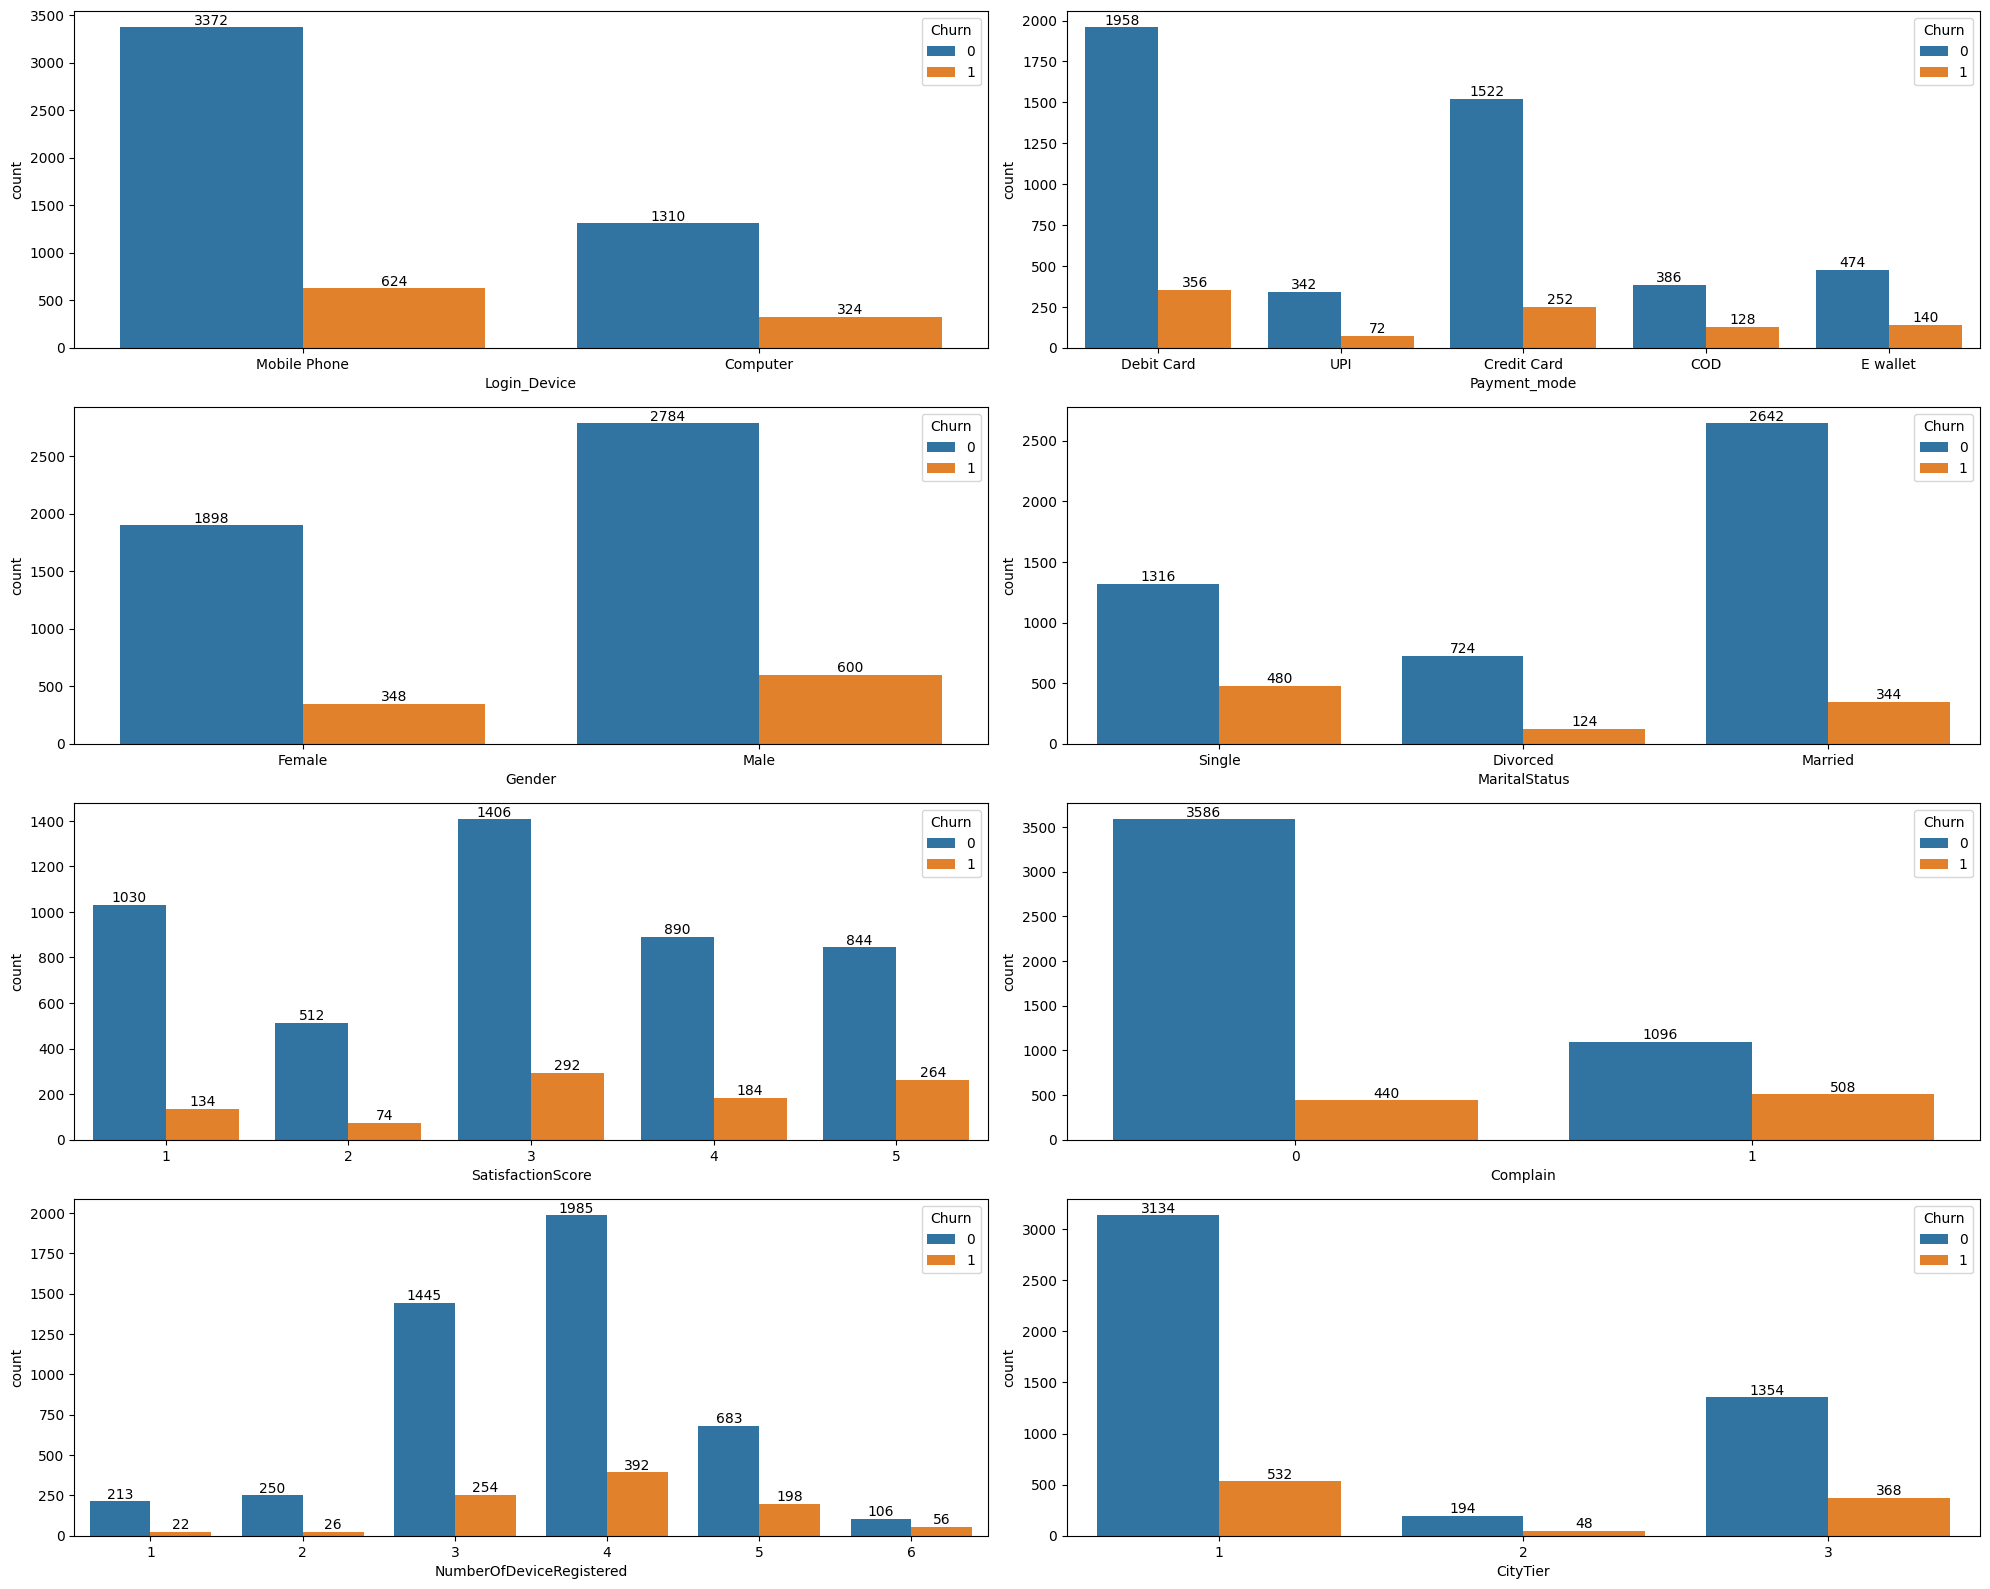

In [ ]:
# Plot count plots for selected categorical features to compare
# the distribution of customers based on their churn status.

plt.figure(figsize=(20, 16))

# List of categorical features to visualize.
bar = [
    'Login_Device', 'Payment_mode', 'Gender',
    'MaritalStatus', 'SatisfactionScore', 'Complain',
    'NumberOfDeviceRegistered', 'CityTier'
]

# Create a count plot for each feature.
for i in range(len(bar)):
    plt.subplot(4, 2, i + 1)

    ax = sns.countplot(
        data=df_1,
        x=bar[i],
        hue='Churn'
    )

    # Display the count on top of each bar.
    for container in ax.containers:
        ax.bar_label(container)

# Adjust spacing between the plots.
plt.tight_layout()

# Display all the count plots.
plt.show()

In [ ]:
# Create a DataFrame containing only the selected numerical features
# and the target variable for correlation analysis.
df_heatmap = df_1[
    [
        'Churn', 'Tenure', 'WarehouseToHome',
        'NumberOfAddress', 'OrderAmountHikeFromlastYear',
        'CouponUsed', 'OrderCount', 'DaySinceLastOrder',
        'CashbackAmount', 'NumberOfDeviceRegistered',
        'Complain', 'SatisfactionScore',
        'HourSpendOnApp'
    ]
]

# Calculate and display the Pearson correlation matrix.
# This helps identify the strength and direction of the
# relationship between the selected variables.
print(df_heatmap.corr())

                                Churn    Tenure  WarehouseToHome  \
Churn                        1.000000 -0.345195         0.069544   
Tenure                      -0.345195  1.000000        -0.005273   
WarehouseToHome              0.069544 -0.005273         1.000000   
NumberOfAddress              0.043931  0.248633        -0.008305   
OrderAmountHikeFromlastYear -0.007075  0.001950         0.038311   
CouponUsed                  -0.001430  0.125863         0.002675   
OrderCount                  -0.024038  0.186349         0.000354   
DaySinceLastOrder           -0.155871  0.201630         0.020253   
CashbackAmount              -0.154118  0.509823         0.000415   
NumberOfDeviceRegistered     0.107939  0.000175         0.023020   
Complain                     0.250188 -0.017866         0.026825   
SatisfactionScore            0.105481 -0.020414         0.007524   
HourSpendOnApp               0.018816  0.015048         0.064069   

                             NumberOfAddress  O

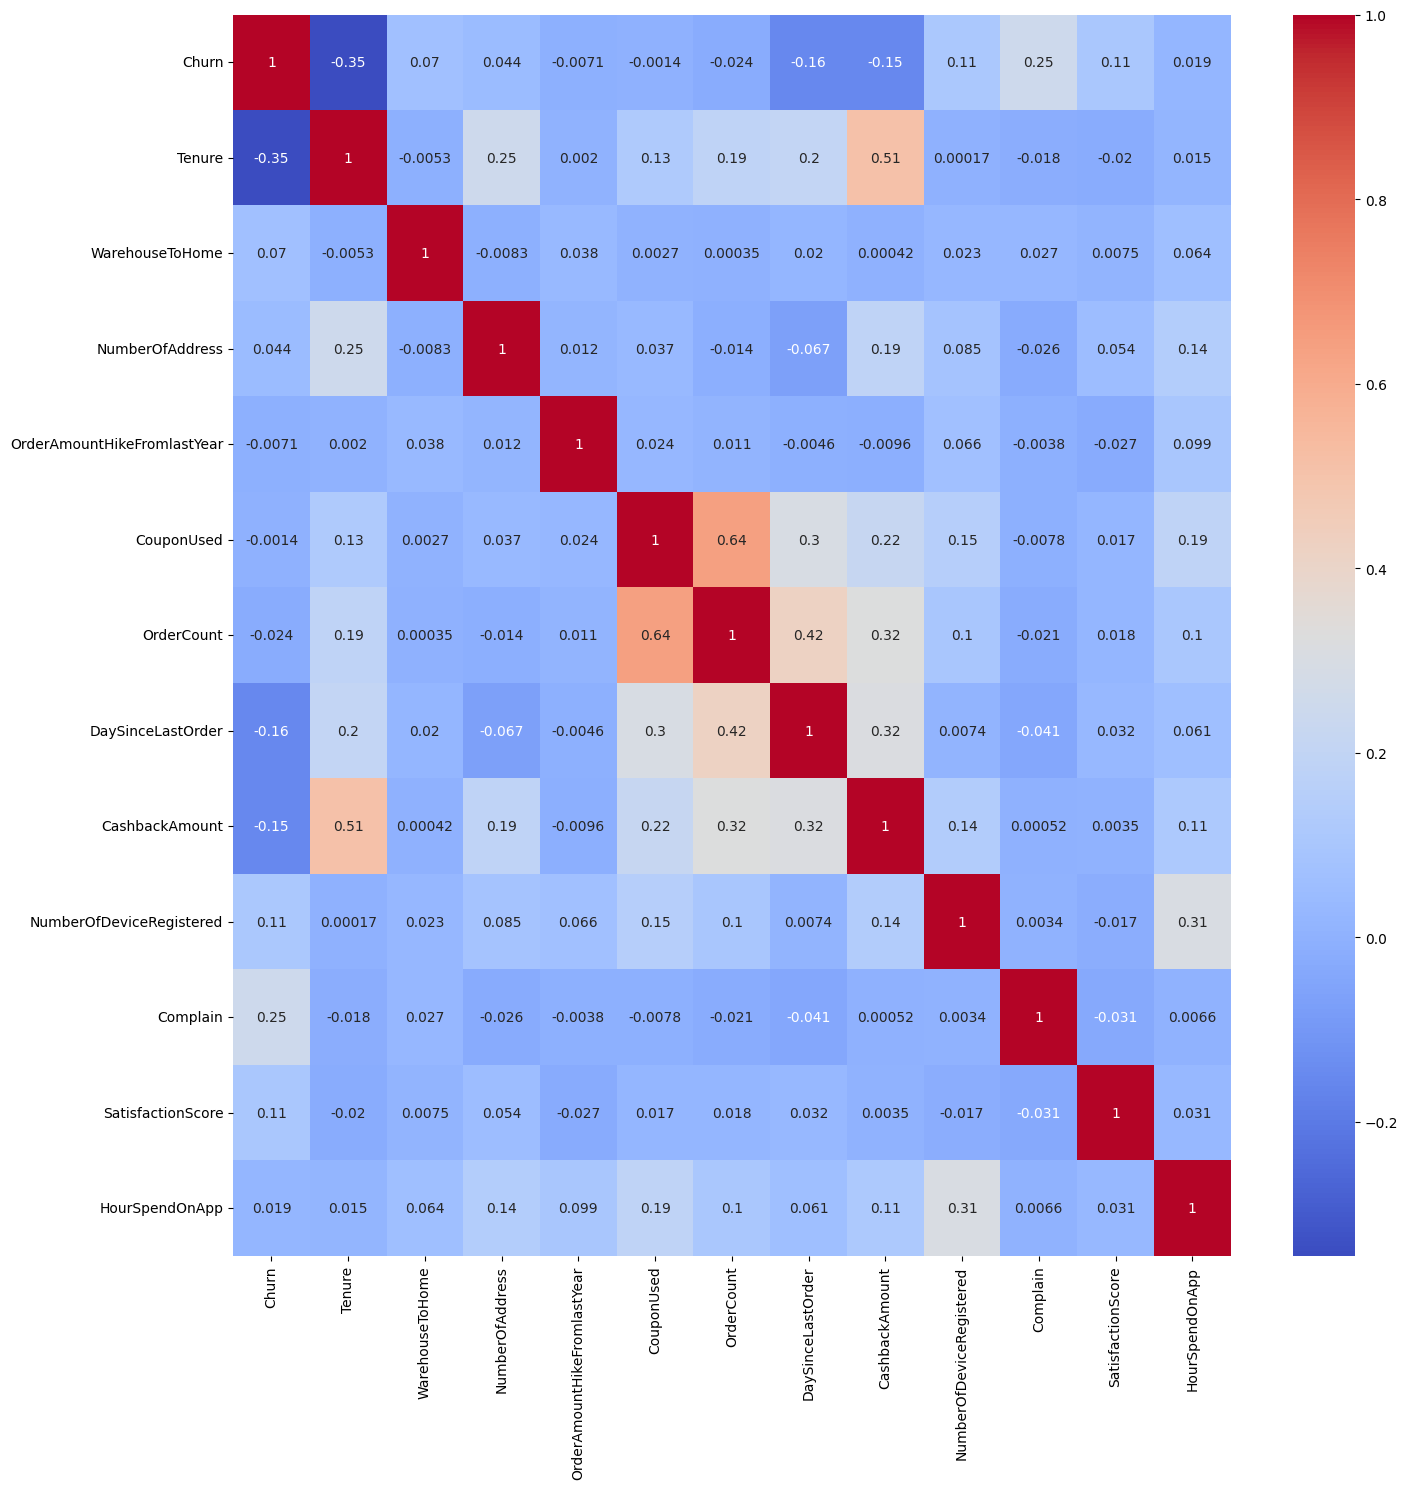

In [ ]:
# Plot a correlation heatmap to visualize the relationship between features.
# The correlation coefficient ranges from -1 to +1.

plt.figure(figsize=(15, 15))

sns.heatmap(
    data=df_heatmap.corr(),
    annot=True,          # Display the correlation values in each cell.
    cmap='coolwarm'      # Use a color map where blue indicates negative and red indicates positive correlation.
)

# Adjust the layout so labels and annotations fit properly.
plt.tight_layout()

# Display the heatmap.
plt.show()

In [ ]:
# Understanding the columns and types
df_1.head()

,Churn,Tenure,Login_Device,CityTier,WarehouseToHome,Payment_mode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,Category,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,1,4,Mobile Phone,3,6,Debit Card,Female,3,3,Laptop & Accessory,2,Single,9,1,11,1,1,5,159.93
1,1,0,Mobile Phone,1,8,UPI,Male,3,4,Mobile,3,Single,7,1,15,0,1,0,120.90
2,1,0,Mobile Phone,1,30,Debit Card,Male,2,4,Mobile,3,Single,6,1,14,0,1,3,120.28
3,1,0,Mobile Phone,3,15,Debit Card,Male,2,4,Laptop & Accessory,5,Single,8,0,23,0,1,3,134.07
4,1,0,Mobile Phone,1,12,Credit Card,Male,3,3,Mobile,5,Single,3,0,11,1,1,3,129.60


In [ ]:
# Create a new DataFrame by removing the target variable (Churn).
# This leaves only the input features for preprocessing and model training.
df_2 = df_1.drop(columns=['Churn'])

# Display the first five rows of the feature dataset.
print(df_2.head())

# Display the frequency of each category in the MaritalStatus column.
print(df_2['MaritalStatus'].value_counts())

   Tenure  Login_Device  CityTier  WarehouseToHome Payment_mode  Gender  \
0       4  Mobile Phone         3                6   Debit Card  Female   
1       0  Mobile Phone         1                8          UPI    Male   
2       0  Mobile Phone         1               30   Debit Card    Male   
3       0  Mobile Phone         3               15   Debit Card    Male   
4       0  Mobile Phone         1               12  Credit Card    Male   

   HourSpendOnApp  NumberOfDeviceRegistered            Category  \
0               3                         3  Laptop & Accessory   
1               3                         4              Mobile   
2               2                         4              Mobile   
3               2                         4  Laptop & Accessory   
4               3                         3              Mobile   

   SatisfactionScore MaritalStatus  NumberOfAddress  Complain  \
0                  2        Single                9         1   
1               

In [ ]:
# Convert binary categorical variables into numerical values using label mapping.
df_2['Login_Device'] = df_2['Login_Device'].map({'Mobile Phone': 1, 'Computer': 0})
df_2['Gender'] = df_2['Gender'].map({'Female': 0, 'Male': 1})

# Rename the columns to make their meanings clearer.
df_2.rename(
    columns={
        'Login_Device': 'Is_mobile_phone',
        'Gender': 'Is_male'
    },
    inplace=True
)

# Ensure both columns have integer data types.
df_2['Is_mobile_phone'] = df_2['Is_mobile_phone'].astype(int)
df_2['Is_male'] = df_2['Is_male'].astype(int)

# Display the first five rows of the updated dataset.
df_2.head()


,Tenure,Is_mobile_phone,CityTier,WarehouseToHome,Payment_mode,Is_male,HourSpendOnApp,NumberOfDeviceRegistered,Category,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,4,1,3,6,Debit Card,0,3,3,Laptop & Accessory,2,Single,9,1,11,1,1,5,159.93
1,0,1,1,8,UPI,1,3,4,Mobile,3,Single,7,1,15,0,1,0,120.90
2,0,1,1,30,Debit Card,1,2,4,Mobile,3,Single,6,1,14,0,1,3,120.28
3,0,1,3,15,Debit Card,1,2,4,Laptop & Accessory,5,Single,8,0,23,0,1,3,134.07
4,0,1,1,12,Credit Card,1,3,3,Mobile,5,Single,3,0,11,1,1,3,129.60


In [ ]:
# Convert categorical variables into numerical columns using One-Hot Encoding.
df_3 = pd.get_dummies(
    df_2,
    columns=['Payment_mode', 'Category', 'MaritalStatus', 'CityTier']
)

# Convert the generated boolean columns (True/False) to integers (1/0).
for i in df_3.columns:
    if df_3[i].dtype == 'bool':
        df_3[i] = df_3[i].astype(int)

# Display the first five rows of the encoded dataset.
df_3.head()

# Create a copy of the encoded dataset for feature scaling.
df_scaled_1h = df_3.copy()

# Display the first five rows of the copied dataset.
df_scaled_1h.head()

,Tenure,Is_mobile_phone,WarehouseToHome,Is_male,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,...,Category_Laptop & Accessory,Category_Mobile,Category_Mobile Phone,Category_Others,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,CityTier_1,CityTier_2,CityTier_3
0,4,1,6,0,3,3,2,9,1,11,...,1,0,0,0,0,0,1,0,0,1
1,0,1,8,1,3,4,3,7,1,15,...,0,1,0,0,0,0,1,1,0,0
2,0,1,30,1,2,4,3,6,1,14,...,0,1,0,0,0,0,1,1,0,0
3,0,1,15,1,2,4,5,8,0,23,...,1,0,0,0,0,0,1,0,0,1
4,0,1,12,1,3,3,5,3,0,11,...,0,1,0,0,0,0,1,1,0,0


In [ ]:
from sklearn.preprocessing import StandardScaler

# Create a StandardScaler object to standardize numerical features.
scaler = StandardScaler()

# List of numerical columns that need to be scaled.
cols = [
    'Tenure', 'WarehouseToHome', 'HourSpendOnApp',
    'OrderAmountHikeFromlastYear', 'CouponUsed',
    'OrderCount', 'DaySinceLastOrder',
    'CashbackAmount', 'NumberOfDeviceRegistered',
    'SatisfactionScore', 'NumberOfAddress'
]

# Fit the scaler on the selected columns and transform them.
# The scaled values replace the original numerical values.
df_scaled_1h[cols] = scaler.fit_transform(df_scaled_1h[cols])

# Display the first five rows of the scaled dataset.
df_scaled_1h.head()

,Tenure,Is_mobile_phone,WarehouseToHome,Is_male,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,...,Category_Laptop & Accessory,Category_Mobile,Category_Mobile Phone,Category_Others,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,CityTier_1,CityTier_2,CityTier_3
0,-0.661729,1,-1.146379,0,0.092654,-0.67290,-0.772992,1.852616,1,-1.301849,...,1,0,0,0,0,0,1,0,0,1
1,-1.125451,1,-0.906721,1,0.092654,0.30375,-0.048392,1.078430,1,-0.187872,...,0,1,0,0,0,0,1,1,0,0
2,-1.125451,1,1.729519,1,-1.324850,0.30375,-0.048392,0.691336,1,-0.466367,...,0,1,0,0,0,0,1,1,0,0
3,-1.125451,1,-0.067917,1,-1.324850,0.30375,1.400807,1.465523,0,2.040082,...,1,0,0,0,0,0,1,0,0,1
4,-1.125451,1,-0.427405,1,0.092654,-0.67290,1.400807,-0.469944,0,-1.301849,...,0,1,0,0,0,0,1,1,0,0


In [ ]:
from sklearn.model_selection import train_test_split

# Separate the dataset into input features (X) and target variable (Y).
x = df_3
y = df_1['Churn']

# Store the scaled dataset for later use in models that require feature scaling.
x_scaled = df_scaled_1h


In [ ]:
# Split the dataset into training (80%) and testing (20%) sets
# random_state=42 ensures the same split every time.

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)


# Create a StandardScaler object to standardize numerical features.
scaler = StandardScaler()

# List of numerical columns to scale.
cols = [
    'Tenure', 'WarehouseToHome', 'HourSpendOnApp',
    'OrderAmountHikeFromlastYear', 'CouponUsed',
    'OrderCount', 'DaySinceLastOrder',
    'CashbackAmount', 'NumberOfDeviceRegistered',
    'SatisfactionScore', 'NumberOfAddress'
]


# Create copies so only the selected numerical columns are scaled.
x_scaled_train = x_train.copy()
x_scaled_test = x_test.copy()


# Fit the scaler on the training data and transform it.
# Use the same scaler to transform the test data.

x_scaled_train[cols] = scaler.fit_transform(x_train[cols])
x_scaled_test[cols] = scaler.transform(x_test[cols])

In [ ]:
# -------------------------------------------------------
# Import Random Forest Classifier
# -------------------------------------------------------
# RandomForestClassifier is an ensemble learning algorithm that
# combines multiple Decision Trees to improve prediction accuracy
# and reduce overfitting.

from sklearn.ensemble import RandomForestClassifier


# -------------------------------------------------------
# Create the Random Forest Model
# -------------------------------------------------------
# n_estimators=100
# -> Builds 100 Decision Trees.
#
# random_state=42
# -> Ensures reproducible results by fixing the random seed.

model_RF = RandomForestClassifier(n_estimators=100, random_state=42)


# -------------------------------------------------------
# Train the Model
# -------------------------------------------------------
# The model learns patterns from the scaled training data.
# (Although Random Forest does not require scaling, it works
# perfectly fine with scaled features.)

model_RF.fit(x_scaled_train, y_train)


# -------------------------------------------------------
# Make Predictions
# -------------------------------------------------------
# Predict the class labels (0 or 1) for the test data.

y_pred = model_RF.predict(x_scaled_test)


# -------------------------------------------------------
# Calculate Accuracy
# -------------------------------------------------------
# Accuracy = (Correct Predictions / Total Predictions)
# Gives the overall percentage of correctly classified samples.

accuracy_score_RF = accuracy_score(y_test, y_pred)


# -------------------------------------------------------
# Generate Confusion Matrix
# -------------------------------------------------------
# Displays the number of:
# True Positives (TP)
# True Negatives (TN)
# False Positives (FP)
# False Negatives (FN)

confusion_matrix_RF = confusion_matrix(y_test, y_pred)


# -------------------------------------------------------
# Generate Classification Report
# -------------------------------------------------------
# Provides:
# Precision
# Recall
# F1-score
# Support
#
# Precision:
# Of all predicted positives, how many were actually positive.
#
# Recall:
# Of all actual positives, how many were correctly identified.
#
# F1-score:
# Harmonic mean of Precision and Recall.

classification_report_RF = classification_report(y_test, y_pred)


# -------------------------------------------------------
# Perform 5-Fold Cross Validation
# -------------------------------------------------------
# The dataset is divided into 5 equal parts.
#
# The model is trained on 4 folds and tested on the remaining fold.
#
# This process repeats 5 times so every fold becomes the test set once.
#
# The average accuracy gives a better estimate of model performance.

score_RF = cross_val_score(model_RF, x, y, cv=5)


# -------------------------------------------------------
# Print Mean Cross Validation Accuracy
# -------------------------------------------------------
print(score_RF.mean())


# -------------------------------------------------------
# Print Test Accuracy
# -------------------------------------------------------
print(accuracy_score_RF)


# -------------------------------------------------------
# Print Confusion Matrix
# -------------------------------------------------------
print(confusion_matrix_RF)


# -------------------------------------------------------
# Print Classification Report
# -------------------------------------------------------
print(classification_report_RF)

0.988277087033748
0.9689165186500888
[[940   1]
 [ 34 151]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       941
           1       0.99      0.82      0.90       185

    accuracy                           0.97      1126
   macro avg       0.98      0.91      0.94      1126
weighted avg       0.97      0.97      0.97      1126



In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# 1. Apply SMOTE to the scaled training data (same data used for best_rf)
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_scaled_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_smote.value_counts().to_dict())

# 2. Re-run GridSearchCV on the SMOTE-balanced training data
rf_smote = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search_smote = GridSearchCV(
    estimator=rf_smote,
    param_grid=param_grid,
    cv=5,
    scoring='recall',   # churn class recall still the priority
    n_jobs=-1,
    verbose=2
)

grid_search_smote.fit(x_train_smote, y_train_smote)

print("Best Parameters (SMOTE):", grid_search_smote.best_params_)
print("Best CV Score (SMOTE):", grid_search_smote.best_score_)

best_rf_smote = grid_search_smote.best_estimator_

# 3. Evaluate on the ORIGINAL (non-SMOTE) test set — this is what matters
y_pred_smote = best_rf_smote.predict(x_scaled_test)
y_prob_smote = best_rf_smote.predict_proba(x_scaled_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_smote))
print(confusion_matrix(y_test, y_pred_smote))
print(classification_report(y_test, y_pred_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_smote))

# 4. Save the SMOTE-trained model (overwrite the deployed artifact)
import joblib
joblib.dump(best_rf_smote, 'Random_Forest.pkl')
joblib.dump(scaler, 'scaler.pkl')           # scaler is unchanged, but re-save for consistency
joblib.dump(x.columns.tolist(), 'columns.pkl')  # columns are unchanged too

Before SMOTE: {0: 3741, 1: 763}
After SMOTE: {0: 3741, 1: 3741}
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters (SMOTE): {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score (SMOTE): 0.9700559748113349
Accuracy: 0.9635879218472468
[[931  10]
 [ 31 154]]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       941
           1       0.94      0.83      0.88       185

    accuracy                           0.96      1126
   macro avg       0.95      0.91      0.93      1126
weighted avg       0.96      0.96      0.96      1126

ROC-AUC: 0.9834592296866473


['columns.pkl']